## What is the problem?

Player have a boundary of gold. A **collector** costs 100 (gold), one **warrior** costs 200 (gold). *I want to maximize my production utility.*

The first step is formulate the problem mathematically.

- $x_c = collector$
- $x_w = warrior$
- $C_u$ = $current$ $units$
- $b$ = $boundary$

The second step is define the constraints.
- We know each cost in terms of gold for each unit, however we have a boundary in the gold, 
- Each variable needs to be positive. (The constraint of consider only integers values is a complex problem
so isn't considered for this project)
- The maximun number of existing units for each player must be less or equal to **50** considering the current units on the game.

1. $x_c, x_w \geq 0$

2. $100*x_c + 200*x_w \leq b$

3. $x_c + x_w \leq 50 - C_u$

We plot the region delimited by the constraint. In this region we have all possible solutions to fulfill the constraint, however we don't know which is the better solution for our problem, we cover these problem in the next step.

In [317]:
import matplotlib.pyplot as plt
import numpy as np

# CONSTANTS for the cost of each existent unit on the game
COST_COLLECTORS = 100
COST_WARRIORS  = 200
MAXIMUM_NUMBER_UNITS = 50
CURRENT_UNITS = 10

# DEFINE the boundary of available gold
BOUNDARY = 6000

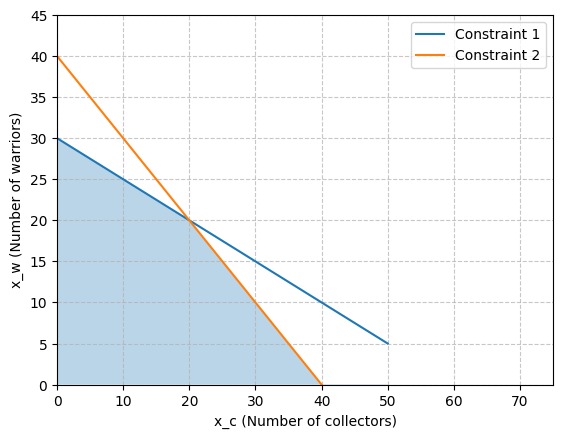

In [318]:
def plot_solution_space(optimal_point=True,x_coord=0,y_coord=0):
    # DEFINE the solution space knowing for the function
    y1 = lambda x: (BOUNDARY - COST_COLLECTORS * x) / COST_WARRIORS
    y2 = lambda x: (MAXIMUM_NUMBER_UNITS - x - CURRENT_UNITS) 

    # COMPUTE how much collectors (x-axis) which could be purchased
    LIMIT = min(BOUNDARY / COST_COLLECTORS, MAXIMUM_NUMBER_UNITS)

    """
    DEFINE the x-axis where the left-limit is zero, 
    and the rigth-limit is the maximum number of collectors which could be purchased with the boundary 
    """
    x = np.linspace(0, LIMIT,100)

    # COMPUTE the values of y taking points of x
    val_y1 = y1(x)
    val_y2 = y2(x)

    # PLOTING the solution taking X and Y
    plt.plot(x,val_y1, label='Constraint 1')
    plt.plot(x,val_y2, label="Constraint 2")

    if optimal_point == True:
        plt.scatter(x_coord,y_coord, color='red', zorder=5, label='optimal point')

    y_intersection = np.minimum(val_y1,val_y2)
    # Fill the space in the space of X and two curves in Y y=0 and y=function defined previously
    plt.fill_between(x, 0, y_intersection, alpha=0.3)

    plt.xlim(0, max(x) * 1.5)
    plt.ylim(0, max(val_y1) * 1.5)
    plt.xlabel('x_c (Number of collectors)')
    plt.ylabel('x_w (Number of warriors)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_solution_space(False)

We want to maximize the utility knowing the cost in terms of gold of each unit and the solution space. However we have to define how much important is to have collectors or warriors, and that definition is given by weigths.

$max($ $\theta_{1} * x_c + \theta_{2} * x_w )$

subject to:

1. $x_c, x_w \geq 0$

2. $100*x_c + 200*x_w \leq 500$

3. $x_c + x_w \leq 50 - x_u$

where:
- $\theta_{1}:$ The importance of having collectors on this state.
- $\theta_{2}:$ The importance of having warriors on this state.

Now with the problem statement we can search a good solution for the problem considering the constraints. We formulate the function to apply with different weigths.

In [319]:
from scipy.optimize import linprog
def linear_programming_solutions(coef, A_ub, b_ub, bounds):
    results = linprog(coef, A_ub=A_ub, b_ub=b_ub, bounds=bounds)
    return results.x[0], results.x[1]

#### First scenario we consider that have collectors is more important than have warriors.

You have to produce 40.0 collectors and 0.0 warriors.


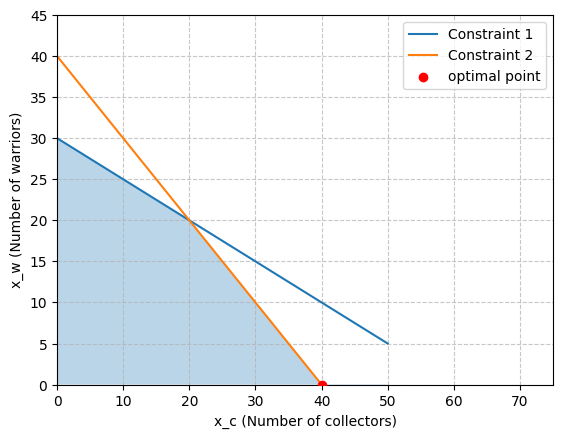

In [320]:
# Coeficients (weigths) of the objective function (denied for maximization)
first_scenario_coeficients = [-1,0]

# Constraint 1: cost_a * xc + cost_b * xw <= budget
# Constraint 2: xc + xw <= 50
A_matrix_constraints = [
    [COST_COLLECTORS, COST_WARRIORS],
    [1,1]
]
b_matrix_boudary = [
    BOUNDARY,
    MAXIMUM_NUMBER_UNITS - CURRENT_UNITS
]

# Bounds for the variables 
bounds = [(0,None), (0,None)]

first_n_collectors, first_n_warriors = linear_programming_solutions(first_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {first_n_collectors} collectors and {first_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=first_n_collectors,y_coord=first_n_warriors)

#### Second scenario we consider that have warriors is more important than have collectors.

You have to produce 0.0 collectors and 30.0 warriors.


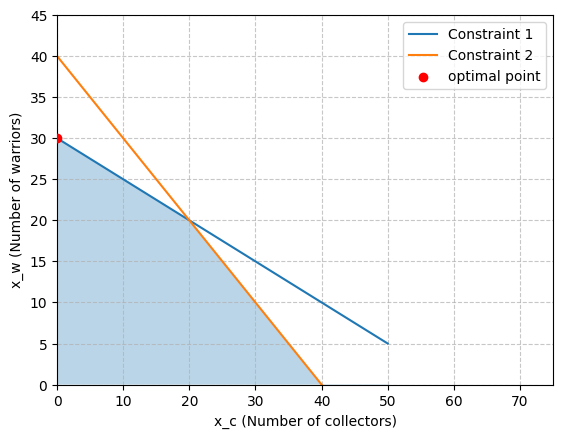

In [321]:
# Coeficients (weigths) of the objective function (denied for maximization)
second_scenario_coeficients = [0,-1]

second_n_collectors, second_n_warriors = linear_programming_solutions(second_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {second_n_collectors} collectors and {second_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=second_n_collectors,y_coord=second_n_warriors)

#### Third scenario we consider that have warriors is equal of important than have collectors.

You have to produce 20.0 collectors and 20.0 warriors.


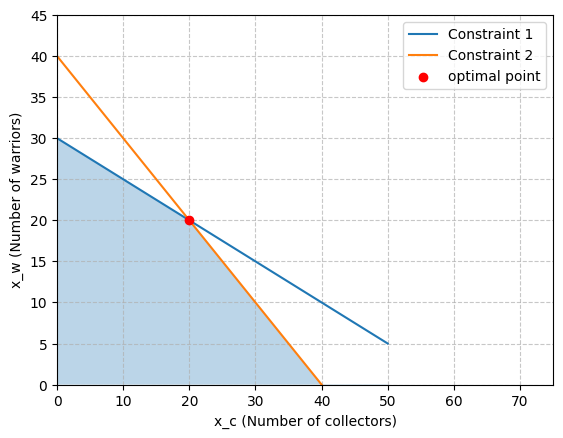

In [322]:
# Coeficients (weigths) of the objective function (denied for maximization)
third_scenario_coeficients = [-1,-1]

third_n_collectors, third_n_warriors = linear_programming_solutions(third_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {third_n_collectors} collectors and {third_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=third_n_collectors,y_coord=third_n_warriors)

#### Fourth scenario we consider that have the double of warriors is more important than have collectors.

Due to the nature of linear programming, it always tends toward one of the vertices.

You have to produce 20.0 collectors and 20.0 warriors.


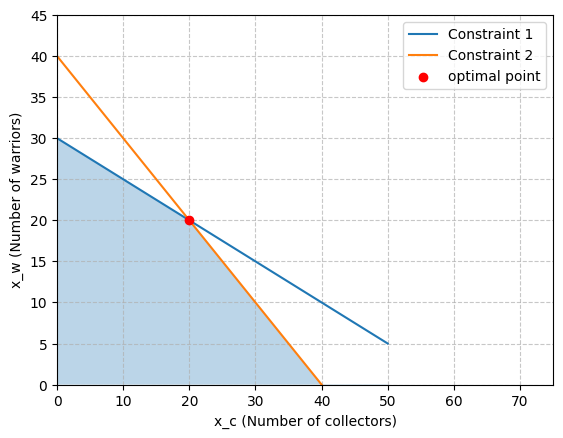

In [323]:
# Coeficients (weigths) of the objective function (denied for maximization)
fourth_scenario_coeficients = [-0.3,-0.5]

fourth_n_collectors, fourth_n_warriors = linear_programming_solutions(fourth_scenario_coeficients, A_matrix_constraints, b_matrix_boudary, bounds)

print(f"You have to produce {fourth_n_collectors} collectors and {fourth_n_warriors} warriors.")
plot_solution_space(optimal_point=True,x_coord=fourth_n_collectors,y_coord=fourth_n_warriors)

### Define the weights function

We defined the problem with their specific constraints to modeling a linear programming (LP) problem using the simplex algorithm to solve.
As we discuted on the previous cells, the function to maximize for the LP problem is:

$max($ $\theta_{1} * x_c + \theta_{2} * x_w )$

subject to:

1. $x_c, x_w \geq 0$

2. $100*x_c + 200*x_w \leq 500$

3. $x_c + x_w \leq 50 - x_u$$

Where $\theta_{1}$ and $\theta_{2}$ define the importance of produce each type of unit. However that weights aren't trivally, we must to formulate a function
that compute the values of the weights considering a lot of vairables in the game. In the section below, we propose that function.

In [ ]:
def get_weights(difficulty):
    pass